# 終端問題、CLN1/CLN2変換、タイル表現

## 終端は省略記号ではなく、近似の一部

同じ途中までの梯子でも、末端を抵抗・インダクタンス・補正インピーダンスのどれにするかで応答が変わります。途中の回路を固定すると、端子Zは終端$Z_t$の一次分数変換になります。下の例では$R_0+(sL_1\parallel(R_2+Z_t))$から必要な終端を逆算します。

正解Zを使って終端を逆算できることは、未知の正解を予測できることと同じではありません。逆算した終端の次数・安定性・受動性も別に確認します。


In [1]:
import sympy as sp
s,R0,L1,R2,target,tail=sp.symbols('s R0 L1 R2 target tail')
Z=R0+s*L1*(R2+tail)/(s*L1+R2+tail)
required=sp.solve(sp.Eq(Z,target),tail)[0]
assert sp.cancel(Z.subs(tail,required)-target)==0
print('Required termination Zt =',sp.factor(required))
print('PASS: symbolic substitution recovers target, wherever denominators are defined')
# A simple exact finite-network conversion, expressed by topology rather than a name.
Ra,La=sp.symbols('Ra La',positive=True)
parallel=Ra*s*La/(Ra+s*La)
admittance=1/Ra+1/(s*La)
assert sp.cancel(parallel-1/admittance)==0
print('PASS: exact rational impedance/admittance identity')


Required termination Zt = -(L1*R0*s + L1*R2*s - L1*s*target + R0*R2 - R2*target)/(L1*s + R0 - target)
PASS: symbolic substitution recovers target, wherever denominators are defined
PASS: exact rational impedance/admittance identity


## CLN1とCLN2は、まず回路式で定義する

旧資料の「Cauer I/II」と現在の展開点付き「Type1/Type2」は、番号だけで対応づけません。端子関数をZ・Y・Z/sのどれで書くか、直列・並列の順、展開点、終端を確認します。

- **有限有理関数の厳密変換**：変換後も同じZを表す。通分した分子の差が恒等的にゼロになることを検査する。
- **別の展開点・次数への近似変換**：有限のTaylor情報を再展開する。同じZになるとは限らないので、係数と帯域誤差を検査する。
- **重み付きLanczos変換**：$Q^TKQ$の直交性と$Q^TQ=I$を混同しない。

上の1枝の恒等式は厳密変換の検査方法の最小例です。一般のCLN1/CLN2変換器を実装した例ではありません。既存変換資料から公開版へ移す際には、変換元・先の回路定義と終端を先に固定します。

## タイル表現は、回路と互除法の関係を見せる

電圧を縦、電流を横に取ると、抵抗の縦横比がRになります。直列は同じ電流で縦に積み、並列は同じ電圧で横に並べます。面積はV×Iです。次の図は正の実数抵抗の説明であり、複素交流電力を面積で表したものではありません。


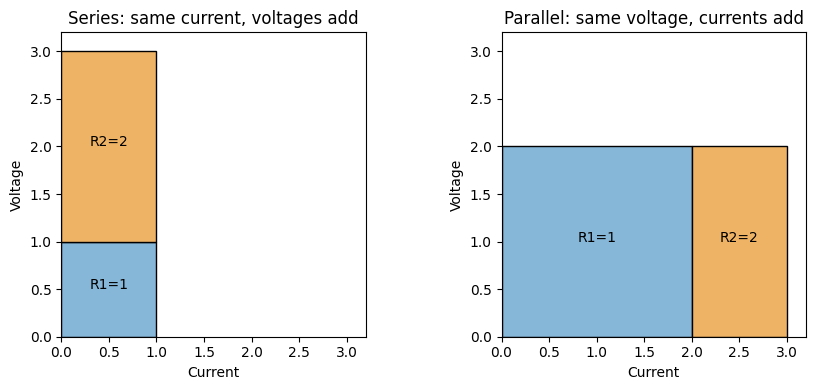

Series R=3; parallel R=2/3; aspect ratios reproduce both


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig,ax=plt.subplots(1,2,figsize=(9,4))
for bottom,height,color,label in [(0,1,'#86b6d8','R1=1'),(1,2,'#efb366','R2=2')]:
    ax[0].add_patch(Rectangle((0,bottom),1,height,facecolor=color,edgecolor='black'))
    ax[0].text(.5,bottom+height/2,label,ha='center')
# Parallel: V=2, I1=2/R1=2, I2=2/R2=1.
for left,width,color,label in [(0,2,'#86b6d8','R1=1'),(2,1,'#efb366','R2=2')]:
    ax[1].add_patch(Rectangle((left,0),width,2,facecolor=color,edgecolor='black'))
    ax[1].text(left+width/2,1,label,ha='center')
for a in ax:a.set(xlim=(0,3.2),ylim=(0,3.2),xlabel='Current',ylabel='Voltage');a.set_aspect('equal')
ax[0].set_title('Series: same current, voltages add')
ax[1].set_title('Parallel: same voltage, currents add')
plt.tight_layout();plt.show()
assert 1+2==3
assert abs(2/3-1/(1/1+1/2))<1e-15
print('Series R=3; parallel R=2/3; aspect ratios reproduce both')


タイル1枚を導体の局所的な薄い層と同一視しません。CLNのモードは領域全体に広がります。複素数・負のqへ、正の実数の長方形の説明をそのまま拡張しないことも重要です。

[入門の回路と段数](00_what_is_cln.ipynb) · [展開点とTypeの違い](01_expansion_and_energy.ipynb)
